# MobileNetV2 3-Class Image Classification with Keras

This notebook trains a 3-class classifier using `MobileNetV2` transfer learning with a configurable `alpha` width multiplier.

In [2]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.21.0
GPU available: False


In [3]:
SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 16
HEAD_EPOCHS = 10
FINETUNE_EPOCHS = 10
ALPHA = 0.35
CLASS_NAMES = ['Amine', 'Jakub', 'Rifki']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('mobilenetv2_3class_classifier.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())
print('Alpha:', ALPHA)

Data root: /Users/jakubpiotrowski/PycharmProjects/HS-Codesign/data
Alpha: 0.35


In [4]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())

,filepath,label
0,../data/Rifki/train/image_20260312_103722_shif...,Rifki
1,../data/Rifki/train/image_20260312_103932_shif...,Rifki
2,../data/Rifki/train/image_20260305_130116_rot.png,Rifki
3,../data/Amine/train/image_20260319_151224_comb...,Amine
4,../data/Jakub/train/image_20260219_163823_brig...,Jakub


Train samples: 3120
label
Amine    1040
Jakub    1040
Rifki    1040
Name: count, dtype: int64

Test samples: 780
label
Amine    260
Jakub    260
Rifki    260
Name: count, dtype: int64


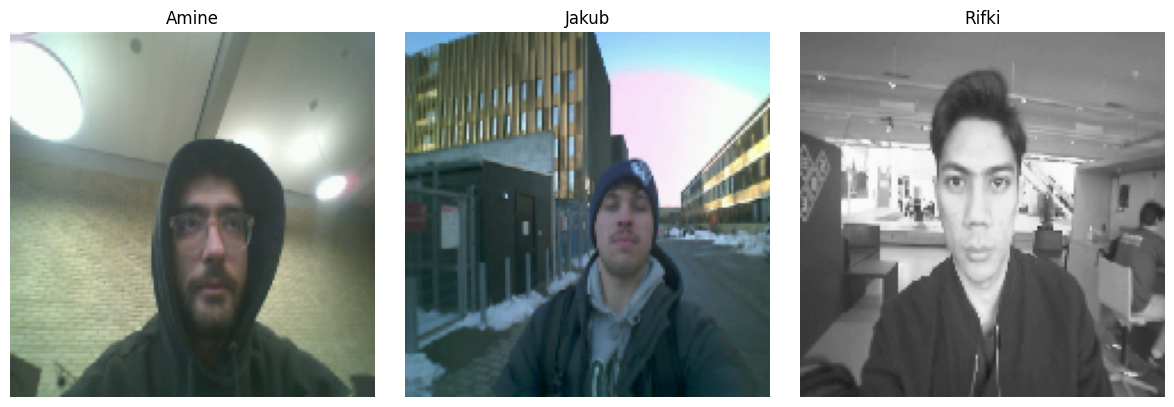

In [5]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class indices:', train_gen.class_indices)

Found 2496 validated image filenames belonging to 3 classes.


Found 624 validated image filenames belonging to 3 classes.
Found 780 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Jakub': 1, 'Rifki': 2}


In [7]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,),
    alpha=ALPHA,
)
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = keras.Model(inputs, outputs, name='MobileNetV2_3Class')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_3Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_160            │ (None, 5, 5, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,563 (2.19 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 410,208 (1.56 MB)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8950 - loss: 0.2702 - val_accuracy: 0.9808 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.9708 - loss: 0.0833 - val_accuracy: 0.9856 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.9848 - loss: 0.0492 - val_accuracy: 0.9920 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.9896 - loss: 0.0391 - val_accuracy: 0.9952 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.9880 - loss: 0.0363 - val_accuracy: 0.9968 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9912 - loss: 0.0345 - val_accuracy: 0.9952 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.9

In [8]:
base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
108/108 [==============================] - 10s 82ms/step - loss: 0.0162 - accuracy: 0.9959 - val_loss: 0.0174 - val_accuracy: 0.9931 - lr: 1.0000e-05
Epoch 2/10
108/108 [==============================] - 9s 79ms/step - loss: 0.0194 - accuracy: 0.9931 - val_loss: 0.0090 - val_accuracy: 0.9977 - lr: 1.0000e-05
Epoch 3/10
108/108 [==============================] - 9s 80ms/step - loss: 0.0186 - accuracy: 0.9925 - val_loss: 0.0028 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/10
108/108 [==============================] - 9s 80ms/step - loss: 0.0145 - accuracy: 0.9954 - val_loss: 0.0169 - val_accuracy: 0.9954 - lr: 1.0000e-05
Epoch 5/10
108/108 [==============================] - 9s 83ms/step - loss: 0.0093 - accuracy: 0.9965 - val_loss: 0.0071 - val_accuracy: 0.9977 - lr: 1.0000e-05
Epoch 6/10
108/108 [==============================] - 9s 80ms/step - loss: 0.0111 - accuracy: 0.9983 - val_loss: 0.0050 - val_accuracy: 1.0000 - lr: 5.0000e-06
Epoch 7/10
108/108 [===================

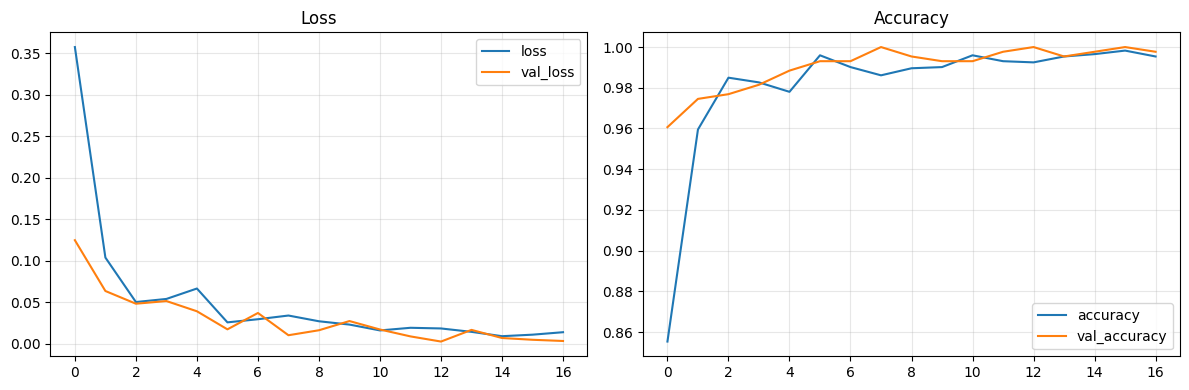

In [9]:
history = {}
for key in history_head.history:
    history[key] = history_head.history[key] + history_finetune.history[key]

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test loss: 0.1450
Test accuracy: 0.9574

              precision    recall  f1-score   support

       Amine       0.92      0.98      0.95       180
       Jakub       0.98      0.89      0.93       180
       Rifki       0.98      1.00      0.99       180

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540



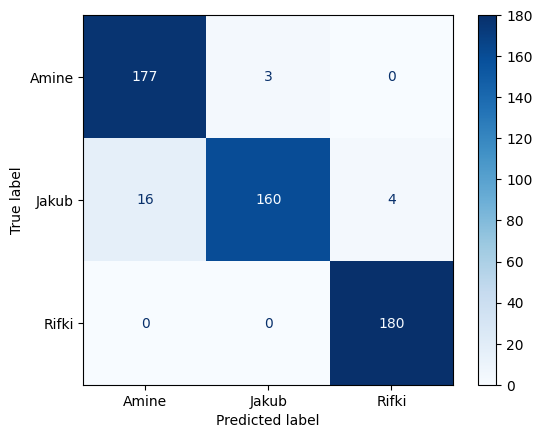

In [10]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()

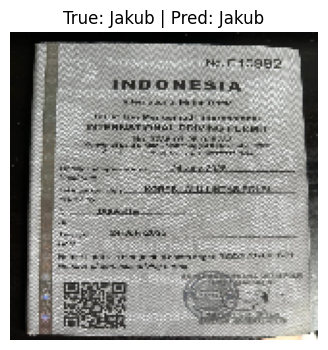

Amine: 0.0010
Jakub: 0.9984
Rifki: 0.0006

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\mobilenetv2_3class_classifier.keras


In [14]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
# sample_path = random_row['filepath']
sample_path = 'simf.jpeg'

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
array = keras.utils.img_to_array(image)
array = preprocess_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(keras.utils.load_img(sample_path, target_size=IMAGE_SIZE))
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print('\nSaved model to:', MODEL_PATH.resolve())

In [12]:
model.summary()

Model: "MobileNetV2_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_0.35_160 (Funct  (None, 5, 5, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)        